In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [65]:
def sample_image(image, factor):
    """
    Downsamples the image by the given factor.
    Args:
        image (numpy array): Original image.
        factor (int): Factor by which to downsample.
    Returns:
        numpy array: Downsampled image.
    """
    height, width = image.shape[:2]
    sampled_image = cv2.resize(image, (width // factor, height // factor), interpolation=cv2.INTER_NEAREST)
    return sampled_image

def quantize_image(image, levels):
    """
    Reduces the number of grayscale levels in the image.
    Args:
        image (numpy array): Original image.
        levels (int): Number of grayscale levels.
    Returns:
        numpy array: Quantized image.
    """
    quantized_image = np.floor(image / (256 // levels)) * (256 // levels)
    quantized_image = quantized_image.astype(np.uint8)
    return quantized_image

def plot_images(original, sampled, quantized):
    """
    Plots the original, sampled, and quantized images side by side.
    Args:
        original (numpy array): Original image.
        sampled (numpy array): Sampled image.
        quantized (numpy array): Quantized image.
    """
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(original, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(sampled, cmap='gray')
    plt.title('Sampled Image')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(quantized, cmap='gray')
    plt.title('Quantized Image')
    plt.axis('off')

    plt.show()


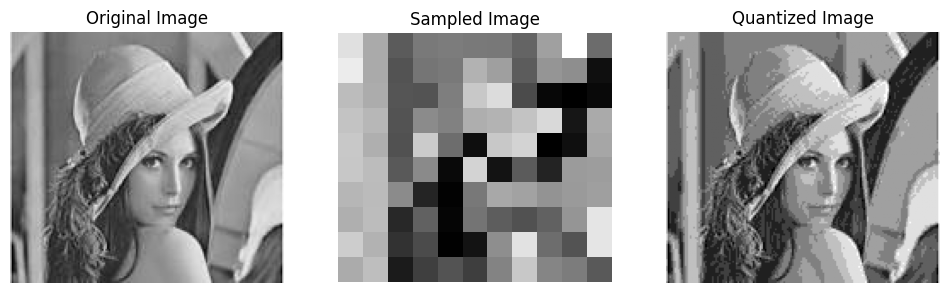

In [91]:
image_path='images/lena_gray_256.png'
sampling_factor=14
quantization_levels=9

# Load image in grayscale
original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
if original_image is None:
    print(f"Error: Unable to load image at {image_path}")

# Sample and quantize
sampled_image = sample_image(original_image, sampling_factor)
quantized_image = quantize_image(original_image, quantization_levels)

# Plot results
plot_images(original_image, sampled_image, quantized_image)


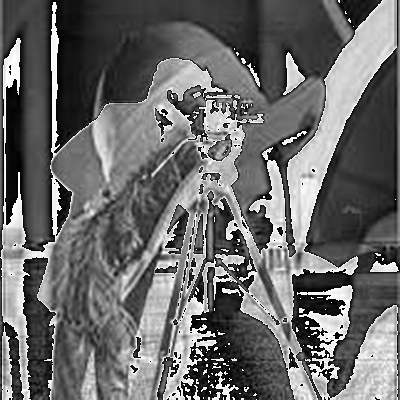

In [93]:
from PIL import Image
img1=Image.open('images/lena_gray_256.png')
img2=Image.open ('images/cameraman.png')

resize=(400,400)
img1=img1.resize(resize,Image.Resampling.LANCZOS)
img2=img2.resize(resize,Image.Resampling.LANCZOS)

im1arr=np.asarray(img1)
im2arr=np.asarray(img2)

addition=im1arr+im2arr
resultImage=Image.fromarray(addition)
resultImage


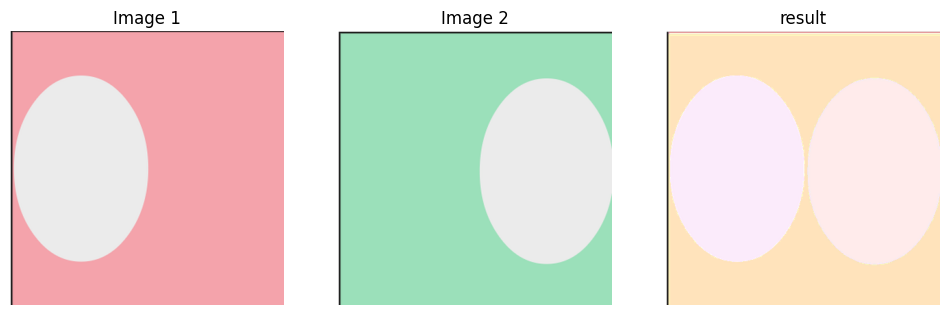

In [94]:
img3=Image.open('images/A.png')
img4=Image.open('images/B.png')

resize=(400,400)
img3=img3.resize(resize,Image.Resampling.LANCZOS)
img4=img4.resize(resize,Image.Resampling.LANCZOS)

im3arr=np.asarray(img3)
im4arr=np.asarray(img4)

union=im4arr|im3arr
resultImage2=Image.fromarray(union)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(img3, cmap='gray')
plt.title('Image 1')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img4, cmap='gray')
plt.title('Image 2')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(resultImage2, cmap='gray')
plt.title('result')
plt.axis('off')

plt.show()


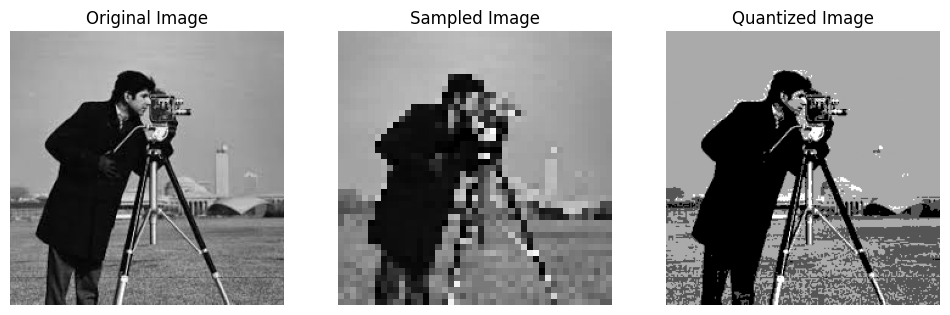

In [90]:
# Task_1

image_path='images/cameraman.tif'
sampling_factor=5
quantization_levels=4

# Load image in grayscale
original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
if original_image is None:
    print(f"Error: Unable to load image at {image_path}")

# Sample and quantize
sampled_image = sample_image(original_image, sampling_factor)
quantized_image = quantize_image(original_image, quantization_levels)

# Plot results
plot_images(original_image, sampled_image, quantized_image)


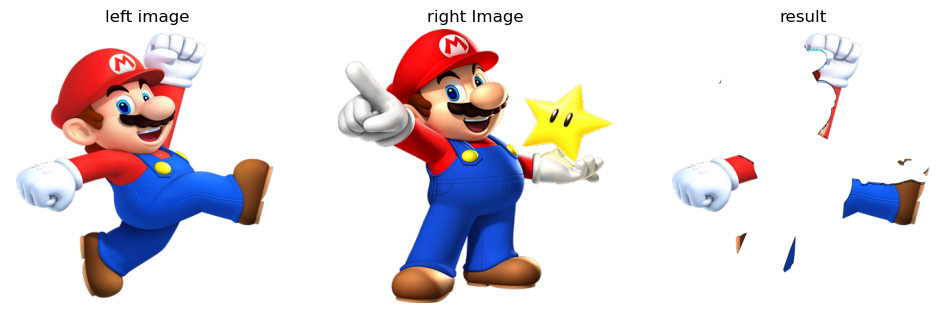

In [10]:
# Task_2 - 1.Subtract two images and display the result.

from PIL import Image, ImageChops
img1=Image.open('images/mario1.png')
img2=Image.open ('images/mario2.png')

resize=(400,400)
img1=img1.resize(resize,Image.Resampling.LANCZOS)
img2=img2.resize(resize,Image.Resampling.LANCZOS)

result = ImageChops.subtract(img1, img2)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(img1, cmap='gray')
plt.title('left image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img2, cmap='gray')
plt.title('right Image')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(result, cmap='gray')
plt.title('result')
plt.axis('off')

plt.show()

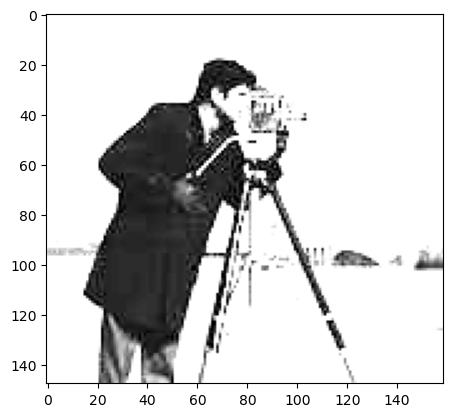

In [8]:
# Task_2 - 2.Add one image with a constant value of 175 and display it.

original_image = cv2.imread('images/cameraman.tif', cv2.IMREAD_GRAYSCALE)
result = cv2.add(original_image, 175)
plt.imshow(result, cmap='gray')

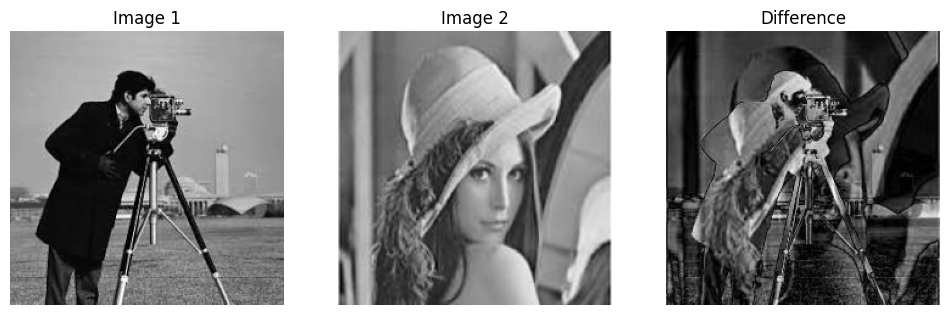

In [95]:
# Task_2 - 3.Apply the set difference operation on two Gray-Scale images. 

import cv2
import matplotlib.pyplot as plt

img1 = cv2.imread("images/cameraman.tif", cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread("images/lena_gray_256.jpg", cv2.IMREAD_GRAYSCALE)

img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

result = cv2.absdiff(img1, img2)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(img1, cmap='gray')
plt.title('Image 1')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img2, cmap='gray')
plt.title('Image 2')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(result, cmap='gray')
plt.title('Difference')
plt.axis('off')

plt.show()


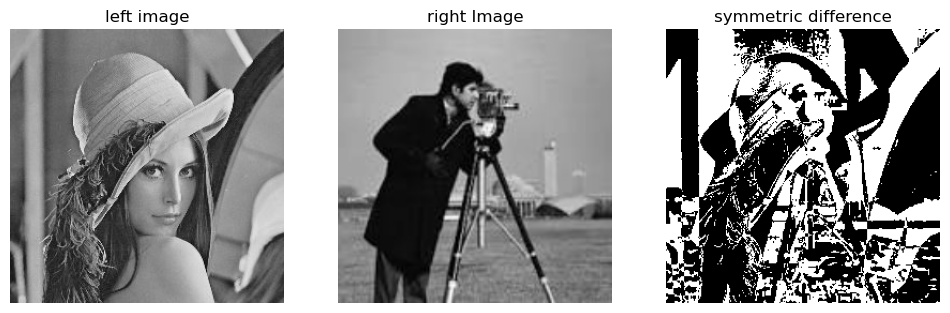

In [12]:
# Task_2 - 4.Apply the symmetric difference operation on two Gray-Scale images.

def quantize_image(img, levels):
    step = 256 // levels
    quantized = (img // step) * step
    return quantized.astype(np.uint8)

img1 = cv2.imread("images/lena_gray_256.jpg", cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread("images/cameraman.tif", cv2.IMREAD_GRAYSCALE)

img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

sym_diff = cv2.bitwise_xor(img1, img2)
result = quantize_image(sym_diff, 2)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(img1, cmap='gray')
plt.title('left image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img2, cmap='gray')
plt.title('right Image')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(result, cmap='gray')
plt.title('symmetric difference')
plt.axis('off')

plt.show()

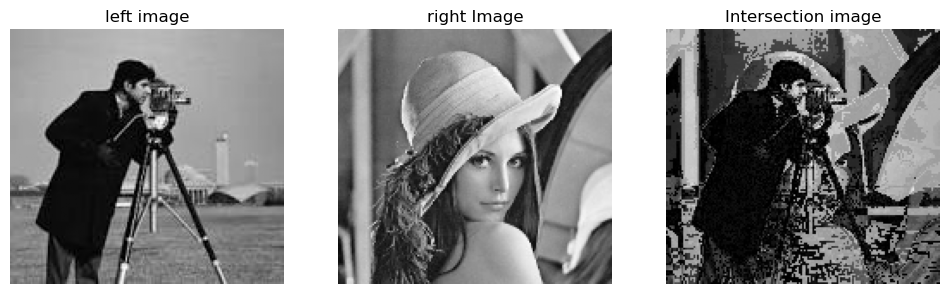

In [5]:
# Task_2 - 5.Apply Intersection operations on two Gray-Scale images. 
 
img1 = cv2.imread("images/cameraman.tif", cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread("images/lena_gray_256.jpg", cv2.IMREAD_GRAYSCALE)

img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))


int_diff = cv2.bitwise_and(img1, img2)


plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(img1, cmap='gray')
plt.title('left image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img2, cmap='gray')
plt.title('right Image')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(int_diff, cmap='gray')
plt.title('Intersection image')
plt.axis('off')

plt.show()